# 🔍 Phase 01 | Exploratory Data Analysis (EDA) & Feature Engineering Pipeline
# 🔍 Fase 01 | Análisis Exploratorio de Datos (EDA) y Pipeline de Ingeniería de Características

> **🎯 Objective / Objetivo:** Clean, harmonize, and architect raw transactional retail datasets into high-signal feature vectors for predictive modeling.  
> **⚙️ Core Stack / Tecnologías:** `Pandas`, `NumPy`, `Seaborn / Matplotlib`, `Time-Series Feature Extraction`

**🇬🇧 EN:** High-performing predictive architectures rely fundamentally on data quality and signal density. In this initial phase, we process over 420,000 multi-source transaction records from Walmart's retail ecosystem. We resolve temporal granularity issues, handle missing promotional markdowns via imputation strategies, decompose cyclical date components, and quantify statistical correlations to eliminate redundant noise before feeding downstream algorithms.

**🇲🇽 ES:** Las arquitecturas predictivas de alto rendimiento dependen fundamentalmente de la calidad de datos y la densidad de señal. En esta fase inicial procesamos más de 420,000 registros transaccionales multifuente del ecosistema minorista de Walmart. Resolvemos granularidades temporales, gestionamos promociones faltantes mediante estrategias de imputación, descomponemos componentes cíclicos de fechas y cuantificamos correlaciones estadísticas para eliminar ruido redundante antes de alimentar los algoritmos posteriores.

---

In [2]:
# ==============================================================================
# 00 | ENVIRONMENT SETUP & VISUAL BLUEPRINT
# 00 | CONFIGURACIÓN DEL ENTORNO Y PLANTILLA VISUAL
# ==============================================================================
# 🇬🇧 EN: Initializing computational dependencies and standardizing color typography.
# 🇲🇽 ES: Inicializando dependencias de cómputo y estandarizando tipografía y paleta de color.

import warnings
warnings.filterwarnings('ignore')

# 1. Core Data Manipulation / Manipulación de Datos
import pandas as pd
import numpy as np

# 2. Visualization Suite / Suite de Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 3. Project-wide Analogous Color Architecture
# Paleta análoga unificada para todo el proyecto
COLOR_PRIMARY = "#7F26D9"    # Morado principal
COLOR_SECONDARY = "#D926D9"  # Magenta
COLOR_ACCENT = "#2626D9"     # Azul profundo
COLOR_NEUTRAL = "#B0BEC5"    # Gris neutro

sns.set_theme(style="white", palette="muted")
plt.rcParams.update({
    'figure.autolayout': True,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.size': 10
})

print("✅ [SYSTEM] Environment configured. Global style rules and palette locked.")
print("✅ [SISTEMA] Entorno configurado. Reglas globales de estilo y paleta bloqueadas.")

✅ [SYSTEM] Environment configured. Global style rules and palette locked.
✅ [SISTEMA] Entorno configurado. Reglas globales de estilo y paleta bloqueadas.


In [3]:
# ==============================================================================
# 01 | MULTI-SOURCE INGESTION & RELATIONAL MERGING
# 01 | INGESTA MULTIFUENTE Y FUSIÓN RELACIONAL
# ==============================================================================
# 🇬🇧 EN: Joining disparate sales, store metadata, and macroeconomic feature sets.
# 🇲🇽 ES: Unificando conjuntos de datos dispersos de ventas, metadatos de tiendas y variables macroeconómicas.

print("⏳ [SYSTEM] Ingesting raw source files from data storage...")

# Adjust relative paths to raw datasets
# Ajustar rutas relativas a los datasets en crudo
path_train = '../data/raw/train.csv'
path_features = '../data/raw/features.csv'
path_stores = '../data/raw/stores.csv'

df_train = pd.read_csv(path_train)
df_features = pd.read_csv(path_features)
df_stores = pd.read_csv(path_stores)

# Relational join across primary foreign keys: ['Store', 'Date'] and ['Store']
# Fusión relacional mediante llaves foráneas primarias
df_raw = df_train.merge(df_features, on=['Store', 'Date', 'IsHoliday'], how='left')
df_raw = df_raw.merge(df_stores, on=['Store'], how='left')

print(f"✅ [SUCCESS] Relational merge completed. Unified shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns.")

⏳ [SYSTEM] Ingesting raw source files from data storage...
✅ [SUCCESS] Relational merge completed. Unified shape: 421,570 rows x 16 columns.


In [4]:
# ==============================================================================
# 02 | FEATURE ENGINEERING & IMPUTATION PROTOCOL
# 02 | PROTOCOLO DE INGENIERÍA DE CARACTERÍSTICAS E IMPUTACIÓN
# ==============================================================================
# 🇬🇧 EN: Imputing markdown values and extracting high-signal temporal features.
# 🇲🇽 ES: Imputando valores de promociones y extrayendo variables temporales clave.

print("⏳ [SYSTEM] Commencing feature transformation pipeline...")

df_clean = df_raw.copy()

# 1. Markdown Sparsity Imputation / Imputación de Promociones
# NaN indicates absence of promotional discount; impute 0.0 to retain numerical signal
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df_clean[markdown_cols] = df_clean[markdown_cols].fillna(0.0)

# 2. Macroeconomic & Environmental Missing Value Management
# Linear interpolation along temporal index to preserve trend continuity
df_clean['CPI'] = df_clean['CPI'].interpolate(method='linear')
df_clean['Unemployment'] = df_clean['Unemployment'].interpolate(method='linear')

# 3. Temporal Decomposition / Descomposición Temporal
# Parsing date vector to harvest cyclical calendar patterns
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Week'] = df_clean['Date'].dt.isocalendar().week.astype(int)

# 4. Outlier & Negative Sales Verification
# Filter out non-physical sales returns or transaction anomalies
initial_rows = len(df_clean)
df_clean = df_clean[df_clean['Weekly_Sales'] > 0]
removed_anomalies = initial_rows - len(df_clean)

print(f"✅ [SUCCESS] MarkDown features imputed with zero-baseline.")
print(f"✅ [SUCCESS] Temporal components isolated: Year, Month, Week.")
print(f"✅ [SUCCESS] Anomalies purged: {removed_anomalies:,} records with non-positive sales.")
print(f"✅ [SUCCESS] Post-cleaning structure: {df_clean.shape[0]:,} observations.")

⏳ [SYSTEM] Commencing feature transformation pipeline...
✅ [SUCCESS] MarkDown features imputed with zero-baseline.
✅ [SUCCESS] Temporal components isolated: Year, Month, Week.
✅ [SUCCESS] Anomalies purged: 1,358 records with non-positive sales.
✅ [SUCCESS] Post-cleaning structure: 420,212 observations.


⏳ [SYSTEM] Computing Year-over-Year (YoY) weekly aggregations...


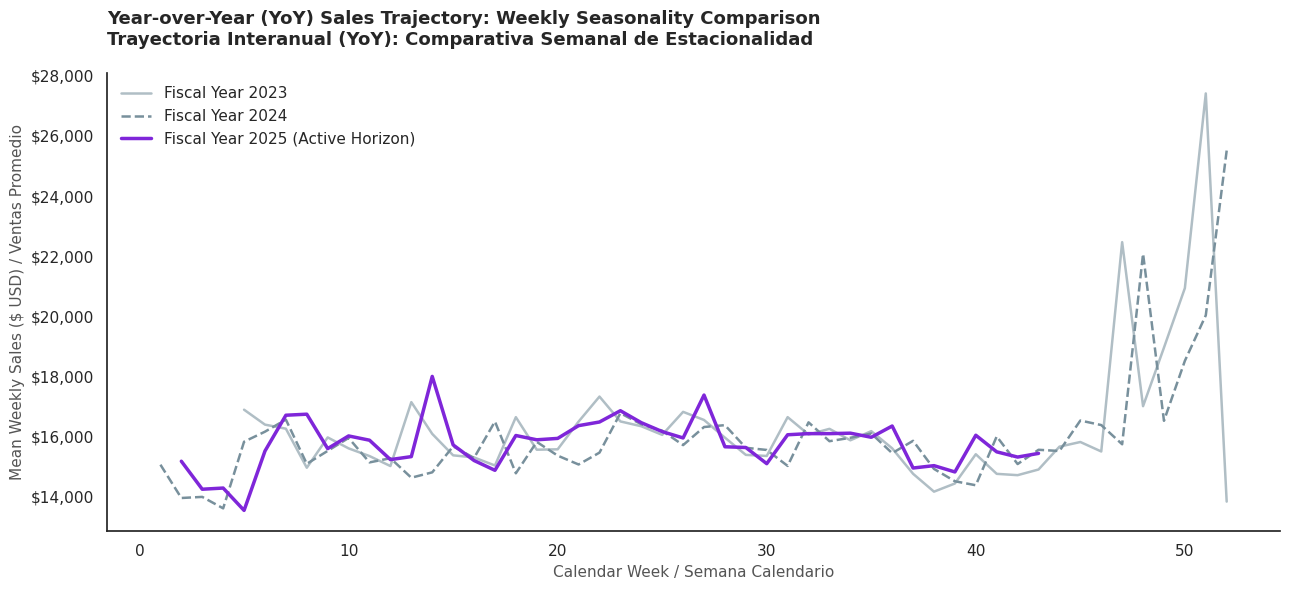

✅ [SUCCESS] YoY seasonality diagnostic exported to '../reports/figures/01_yoy_seasonality_diagnostic.png'


In [5]:
# ==============================================================================
# 04.1 | YEAR-OVER-YEAR (YoY) SEASONALITY DIAGNOSTIC
# 04.1 | DIAGNÓSTICO DE ESTACIONALIDAD INTERANUAL (YoY)
# ==============================================================================
# 🇬🇧 EN: Benchmarking sales trajectories across calendar weeks by operating year.
# 🇲🇽 ES: Comparando trayectorias de ventas a través de semanas calendario por año operativo.

print("⏳ [SYSTEM] Computing Year-over-Year (YoY) weekly aggregations...")

# Agrupación media semanal por año operativo
ventas_yoy = df_clean.groupby(['Year', 'Week'])['Weekly_Sales'].mean().reset_index()

plt.figure(figsize=(13, 6))

# 1. Años históricos como línea base de referencia (Gris neutro)
sns.lineplot(
    data=ventas_yoy[ventas_yoy['Year'] == 2023], 
    x='Week', 
    y='Weekly_Sales', 
    color=COLOR_NEUTRAL, 
    linewidth=1.8, 
    label='Fiscal Year 2023'
)

sns.lineplot(
    data=ventas_yoy[ventas_yoy['Year'] == 2024], 
    x='Week', 
    y='Weekly_Sales', 
    color='#78909C',  # Variante de contraste neutro
    linewidth=1.8, 
    linestyle='--', 
    label='Fiscal Year 2024'
)

# 2. Año más reciente destacado (Morado corporativo)
sns.lineplot(
    data=ventas_yoy[ventas_yoy['Year'] == 2025], 
    x='Week', 
    y='Weekly_Sales', 
    color=COLOR_PRIMARY, 
    linewidth=2.5, 
    label='Fiscal Year 2025 (Active Horizon)'
)

# Títulos y formateo
plt.title(
    'Year-over-Year (YoY) Sales Trajectory: Weekly Seasonality Comparison\n'
    'Trayectoria Interanual (YoY): Comparativa Semanal de Estacionalidad',
    fontsize=13, fontweight='bold', pad=20, loc='left'
)
plt.xlabel('Calendar Week / Semana Calendario', fontsize=11, color='#555555')
plt.ylabel('Mean Weekly Sales ($ USD) / Ventas Promedio', fontsize=11, color='#555555')

plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'${y:,.0f}'))
sns.despine()
plt.legend(loc='upper left', frameon=False)
plt.tight_layout()

# 💾 Exportación automática del gráfico
plt.savefig("../reports/figures/01_yoy_seasonality_diagnostic.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ [SUCCESS] YoY seasonality diagnostic exported to '../reports/figures/01_yoy_seasonality_diagnostic.png'")

⏳ [SYSTEM] Computing correlation matrix across numerical feature space...
⏳ [SYSTEM] Rendering correlation topology using project-wide analogous palette...


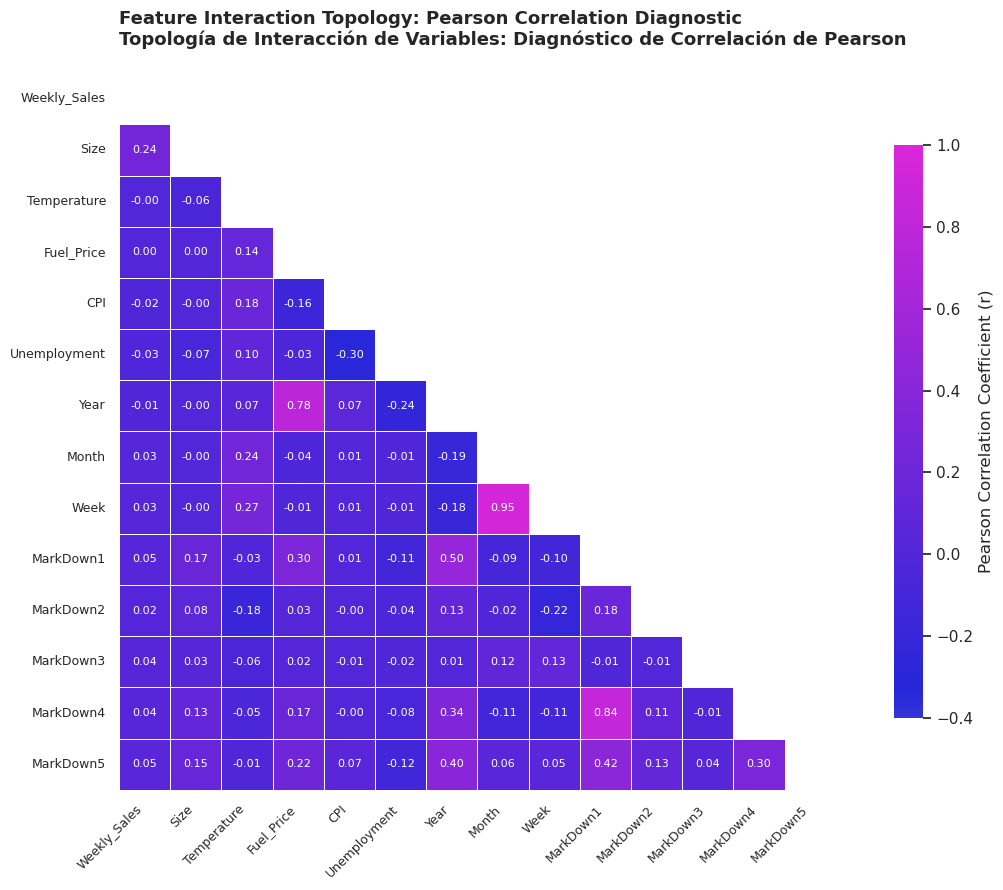

✅ [SUCCESS] Correlation matrix visual exported to '../reports/figures/01_correlation_matrix_diagnostic.png'


In [6]:
# ==============================================================================
# 03 | EXPLORATORY DATA ANALYSIS (EDA) & CORRELATION DIAGNOSTICS
# 03 | ANÁLISIS EXPLORATORIO DE DATOS (EDA) Y DIAGNÓSTICO DE CORRELACIÓN
# ==============================================================================
# 🇬🇧 EN: Diagnosing multicollinearity and feature interactions via heatmap topology.
# 🇲🇽 ES: Diagnosticando multicolinealidad e interacciones entre variables vía mapa de calor.

print("⏳ [SYSTEM] Computing correlation matrix across numerical feature space...")

# 1. Isolation of Numerical Feature Vectors
# Aislamiento de variables numéricas relevantes para modelado
feature_cols = [
    'Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 
    'CPI', 'Unemployment', 'Year', 'Month', 'Week',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5'
]

corr_matrix = df_clean[feature_cols].corr()

# 2. Upper Triangle Mask Construction (Removing redundant visual symmetry)
# Máscara triangular superior para optimizar lectura visual ejecutiva
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Correlation Heatmap Rendering
print("⏳ [SYSTEM] Rendering correlation topology using project-wide analogous palette...")

fig, ax = plt.subplots(figsize=(12, 9))

# Gradiente análogo personalizado: Gris neutro (#B0BEC5) -> Azul (#2626D9) -> Morado (#7F26D9) -> Magenta (#D926D9)
custom_cmap = sns.blend_palette([COLOR_NEUTRAL, COLOR_ACCENT, COLOR_PRIMARY, COLOR_SECONDARY], as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=custom_cmap,
    vmax=1.0,
    vmin=-0.4,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient (r)"},
    annot_kws={"size": 8, "fontweight": "medium"}
)

# Titulación ejecutiva y estilización
plt.title(
    'Feature Interaction Topology: Pearson Correlation Diagnostic\n'
    'Topología de Interacción de Variables: Diagnóstico de Correlación de Pearson',
    fontsize=13, fontweight='bold', pad=20, loc='left'
)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

# 💾 Exportación automática a la suite de reportes
plt.savefig("../reports/figures/01_correlation_matrix_diagnostic.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ [SUCCESS] Correlation matrix visual exported to '../reports/figures/01_correlation_matrix_diagnostic.png'")

⏳ [SYSTEM] Aggregating weekly sales velocity across historical time horizon...
⏳ [SYSTEM] Rendering longitudinal time-series diagnostics...


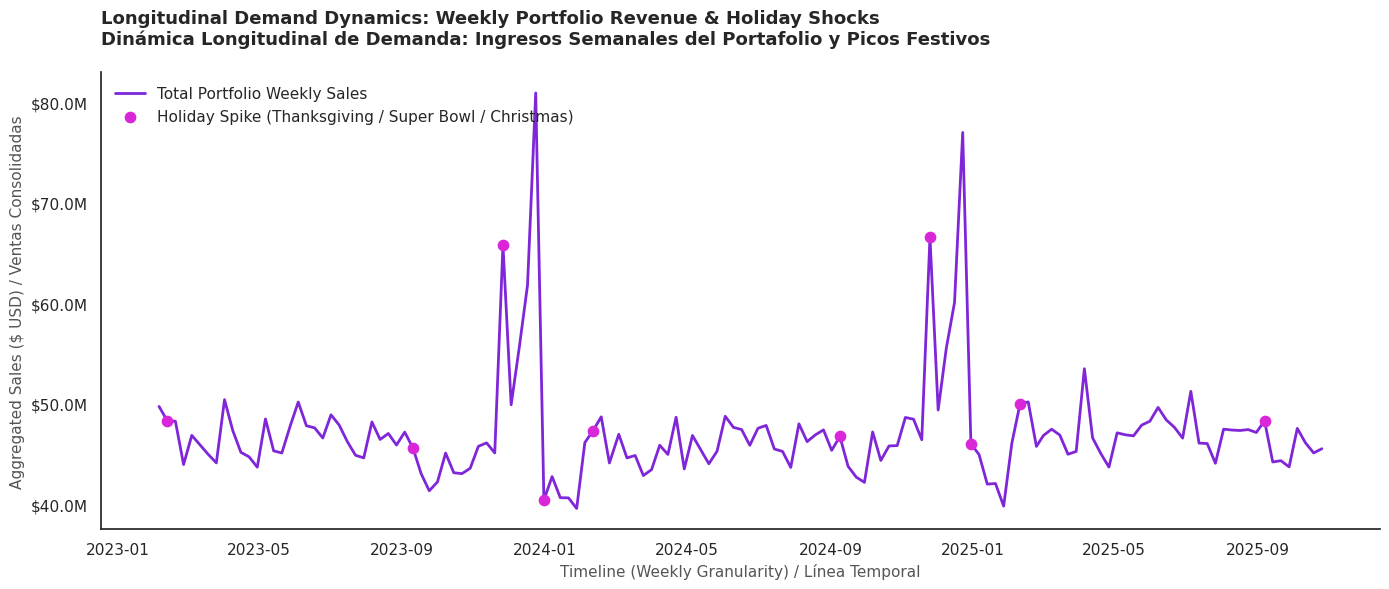

✅ [SUCCESS] Seasonal trend visualization exported to '../reports/figures/01_seasonal_demand_trend.png'


In [7]:
# ==============================================================================
# 04 | SEASONAL DYNAMICS & MACRO TREND ANALYSIS
# 04 | DINÁMICAS ESTACIONALES Y ANÁLISIS DE TENDENCIA MACRO
# ==============================================================================
# 🇬🇧 EN: Extracting cyclical sales velocity across calendar weeks and holiday shifts.
# 🇲🇽 ES: Extrayendo la velocidad cíclica de ventas a lo largo de semanas calendario y festivos.

print("⏳ [SYSTEM] Aggregating weekly sales velocity across historical time horizon...")

# 1. Weekly Aggregation across Store Portfolio
# Agregación temporal semanal para el portafolio consolidado de tiendas
weekly_trend = (
    df_clean.groupby(['Date', 'IsHoliday'])['Weekly_Sales']
    .sum()
    .reset_index()
    .sort_values('Date')
)

# 2. Visualization Setup
print("⏳ [SYSTEM] Rendering longitudinal time-series diagnostics...")

fig, ax = plt.subplots(figsize=(14, 6))

# Línea base de ventas consolidadas (Morado principal: #7F26D9)
ax.plot(
    weekly_trend['Date'], 
    weekly_trend['Weekly_Sales'], 
    color=COLOR_PRIMARY, 
    linewidth=2.0, 
    label='Total Portfolio Weekly Sales'
)

# Resaltar picos festivos con puntos de acento (Magenta: #D926D9)
holiday_points = weekly_trend[weekly_trend['IsHoliday'] == True]
ax.scatter(
    holiday_points['Date'], 
    holiday_points['Weekly_Sales'], 
    color=COLOR_SECONDARY, 
    s=55, 
    zorder=5, 
    label='Holiday Spike (Thanksgiving / Super Bowl / Christmas)'
)

# 3. Formatting & Corporate Layout
ax.set_title(
    'Longitudinal Demand Dynamics: Weekly Portfolio Revenue & Holiday Shocks\n'
    'Dinámica Longitudinal de Demanda: Ingresos Semanales del Portafolio y Picos Festivos',
    fontsize=13, fontweight='bold', pad=20, loc='left'
)
ax.set_xlabel('Timeline (Weekly Granularity) / Línea Temporal', fontsize=11, color='#555555')
ax.set_ylabel('Aggregated Sales ($ USD) / Ventas Consolidadas', fontsize=11, color='#555555')

# Ejes formateados en Millones de USD ($M)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'${y*1e-6:,.1f}M'))

sns.despine()
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()

# 💾 Exportación automática
plt.savefig("../reports/figures/01_seasonal_demand_trend.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✅ [SUCCESS] Seasonal trend visualization exported to '../reports/figures/01_seasonal_demand_trend.png'")

In [8]:
# ==============================================================================
# 05 | DATASET SERIALIZATION & PIPELINE HANDOFF
# 05 | SERIALIZACIÓN DEL DATASET Y ENTREGA DEL PIPELINE
# ==============================================================================
# 🇬🇧 EN: Persisting the curated, model-ready feature store to processed data storage.
# 🇲🇽 ES: Persistiendo el almacén de características curadas para consumo del modelo.

print("⏳ [SYSTEM] Initiating dataset serialization protocol...")

# 1. Output Path Definition
output_path = '../data/processed/retail_data_processed.csv'

# 2. Export Curated Dataset to CSV
df_clean.to_csv(output_path, index=False)

# 3. Validation and Metadata Verification
rows, cols = df_clean.shape
print("\n" + "="*65)
print(" 💾 ARTIFACT SERIALIZATION REPORT / REPORTE DE SERIALIZACIÓN")
print("="*65)
print(f" 📁 Destination:        {output_path}")
print(f" 📊 Records Exported:   {rows:,} observations")
print(f" 🏷️ Feature Space:      {cols} attributes")
print(f" ⚙️ Downstream Target:  02_Predictive_Models.ipynb")
print("="*65 + "\n")

print("✅ [SUCCESS] Curated dataset persisted successfully.")
print("✅ [SUCCESS] Phase 01 Pipeline complete. Upstream data contract fulfilled.")

⏳ [SYSTEM] Initiating dataset serialization protocol...

 💾 ARTIFACT SERIALIZATION REPORT / REPORTE DE SERIALIZACIÓN
 📁 Destination:        ../data/processed/retail_data_processed.csv
 📊 Records Exported:   420,212 observations
 🏷️ Feature Space:      19 attributes
 ⚙️ Downstream Target:  02_Predictive_Models.ipynb

✅ [SUCCESS] Curated dataset persisted successfully.
✅ [SUCCESS] Phase 01 Pipeline complete. Upstream data contract fulfilled.


## 📋 Architectural Summary & Pipeline Handoff / Resumen Arquitectónico

**🇬🇧 Pipeline Deliverables:**
1. **Relational Harmonization:** Consolidated multi-table disparate sources (`train`, `features`, `stores`) into a unified columnar format.
2. **Signal Density & Cleanliness:** Purged negative transaction anomalies, imputed sparse promotional markdowns (`MarkDown1-5`), and interpolated macroeconomic indicators (`CPI`, `Unemployment`).
3. **Temporal Feature Store:** Decomposed baseline timestamp into cyclical components (`Year`, `Month`, `Week`), preparing the feature matrix for tree-based ensemble learning.
4. **Handoff Artifact:** Exported production-ready artifact to `../data/processed/retail_data_processed.csv` to feed **Phase 02 (Predictive Modeling)**.

**🇲🇽 Entregables del Pipeline:**
1. **Armonización Relacional:** Consolidación de fuentes dispersas (`train`, `features`, `stores`) en una estructura tabular unificada.
2. **Densidad de Señal y Calidad:** Depuración de anomalías transaccionales no positivas, imputación de promociones dispersas (`MarkDown1-5`) e interpolación de métricas macroeconómicas (`CPI`, `Desempleo`).
3. **Almacén de Variables Temporales:** Descomposición del vector temporal en componentes cíclicos (`Año`, `Mes`, `Semana`), optimizando la matriz de variables para modelos de ensambles basados en árboles.
4. **Artefacto de Entrega:** Exportación del conjunto curado a `../data/processed/retail_data_processed.csv` listo para alimentar la **Fase 02 (Modelado Predictivo)**.


## 👤 Applied Data Scientist & Researcher / Científico de Datos Aplicado e Investigador

**Pablo Alberto Santana Flores**  
*Chemical Engineer | PhD in Marine Sciences | Decision Intelligence* 

*   **LinkedIn:** [linkedin.com/in/pablo-santana-mx](https://mx.linkedin.com/in/pablo-santana-mx)
*   **GitHub:** [github.com/Pablo-Santana-MX](https://github.com/Pablo-Santana-MX)